# Dense Point Cloud 분석 & FPFH Radius 추정

depth 이미지 + calib ini → 3D point cloud 생성 후,
각 point에서 최소 N개 이웃이 포함되는 radius를 분석합니다.

In [1]:
import cv2
import numpy as np
import configparser
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. 설정

In [2]:
DATA_DIR = Path("gluefactory/datasets/mitsubishi/dataset_depth")
IMAGE_INDICES = [0, 1, 10, 30, 50, 70, 90]       # 분석할 이미지 인덱스
MIN_NEIGHBORS = 5                # 최소 이웃 수
N_SAMPLE = 5000                  # 분석 샘플 수 (전체 하려면 None)

## 2. 유틸 함수

In [8]:
def parse_calib_ini(ini_path):
    """calib ini에서 K, clip_start, clip_end 파싱"""
    config = configparser.ConfigParser()
    config.read(str(ini_path))
    section = config.sections()[0]

    k_vals = [float(v) for v in config[section]["k_matrix"].split(":")[3].split(",")]
    K = np.array(k_vals, dtype=np.float64).reshape(3, 3)

    clip_start = float(config[section]["clip_start"])
    clip_end = float(config[section]["clip_end"])

    return K, clip_start, clip_end


def depth_to_pointcloud(img_path, ini_path):
    """depth 이미지 + ini → 3D point cloud (nonzero만)"""
    K, clip_start, clip_end = parse_calib_ini(ini_path)
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth_norm = img / 65535.0
    depth_real = clip_start + depth_norm * (clip_end - clip_start)
    depth_real[img == 0] = 0.0

    vs, us = np.where(img > 0)
    zs = depth_real[vs, us]
    xs = (us - cx) * zs / fx
    ys = (vs - cy) * zs / fy
    points_3d = np.stack([xs, ys, zs], axis=1)

    info = {
        "K": K, "clip_start": clip_start, "clip_end": clip_end,
        "img_shape": img.shape, "n_nonzero": len(points_3d),
    }
    return points_3d, info


def compute_knn_distances(points_3d, k=5, n_sample=None, seed=42):
    """각 point에서 k번째 이웃까지의 거리 계산"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d.astype(np.float64))
    kdtree = o3d.geometry.KDTreeFlann(pcd)

    if n_sample is not None and n_sample < len(points_3d):
        indices = np.random.RandomState(seed).choice(len(points_3d), n_sample, replace=False)
    else:
        indices = np.arange(len(points_3d))

    dists_k = []
    for si in indices:
        # k+1: 자기 자신 포함
        _, _, dists = kdtree.search_knn_vector_3d(pcd.points[si], k + 1)
        dists_k.append(np.sqrt(dists[k]))

    return np.array(dists_k)

## 3. Point Cloud 생성 & K-NN 분석

In [9]:
results = {}

print(f"{'Image':>6} | {'Points':>7} | {'5-NN p95':>10} | {'Z range':>16} | {'Z p95':>10}")
print("-" * 65)

for idx in IMAGE_INDICES:
    img_path = DATA_DIR / f"depth_raw_{idx:04d}.png"
    ini_path = DATA_DIR / f"calib_{idx:04d}.ini"

    points_3d, info = depth_to_pointcloud(img_path, ini_path)
    dists = compute_knn_distances(points_3d, k=MIN_NEIGHBORS, n_sample=N_SAMPLE)

    results[idx] = {"points_3d": points_3d, "info": info, "dists": dists}

    z = points_3d[:, 2]
    print(f"{idx:>6d} | {len(points_3d):>7d} | {np.percentile(dists, 95):>10.4f} | "
          f"[{z.min():.1f}, {z.max():.1f}] | {np.percentile(z, 95):>10.2f}")

 Image |  Points |   5-NN p95 |          Z range |      Z p95
-----------------------------------------------------------------
     0 |   76388 |     1.0567 | [340.0, 395.0] |     394.99
     1 |   56950 |     1.0738 | [325.7, 439.5] |     415.53
    10 |   56623 |     1.3870 | [346.3, 432.6] |     406.91
    30 |   72615 |     0.8836 | [341.7, 425.9] |     406.48
    50 |   73483 |     1.1386 | [330.8, 413.3] |     400.00
    70 |   75429 |     1.1307 | [330.5, 410.2] |     400.87
    90 |   75178 |     1.0650 | [345.1, 408.3] |     399.92


In [10]:
## Z축 방향 K-NN 거리 분석
# 3D K-NN에서 찾은 이웃들의 Z축 차이(abs)만 추출
print(f"{'Image':>6} | {'dZ median':>10} {'dZ mean':>10} {'dZ p95':>10} {'dZ max':>10}")
print("-" * 55)

for idx in IMAGE_INDICES:
    pts = results[idx]["points_3d"]
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
    kdtree = o3d.geometry.KDTreeFlann(pcd)

    n_sample = min(N_SAMPLE, len(pts))
    sample_idx = np.random.RandomState(42).choice(len(pts), n_sample, replace=False)

    z_dists = []
    for si in sample_idx:
        _, nn_idx, _ = kdtree.search_knn_vector_3d(pcd.points[si], MIN_NEIGHBORS + 1)
        # nn_idx[0]은 자기 자신, nn_idx[1:]이 이웃
        for ni in nn_idx[1:]:
            z_dists.append(abs(pts[si, 2] - pts[ni, 2]))

    z_dists = np.array(z_dists)
    print(f"{idx:>6d} | {np.median(z_dists):>10.4f} {z_dists.mean():>10.4f} "
          f"{np.percentile(z_dists, 95):>10.4f} {z_dists.max():>10.4f}")

 Image |  dZ median    dZ mean     dZ p95     dZ max
-------------------------------------------------------
     0 |     0.0000     0.0286     0.0000     2.8989
     1 |     0.0916     0.1224     0.5035     1.7088
    10 |     0.1068     0.1818     0.7934     2.2123
    30 |     0.1068     0.1686     0.5798     0.9002
    50 |     0.2441     0.2921     0.6866     2.2124
    70 |     0.0915     0.1483     0.6103     1.4648
    90 |     0.2289     0.2829     0.7781     8.1017


## 4. K-NN 거리 분포 시각화

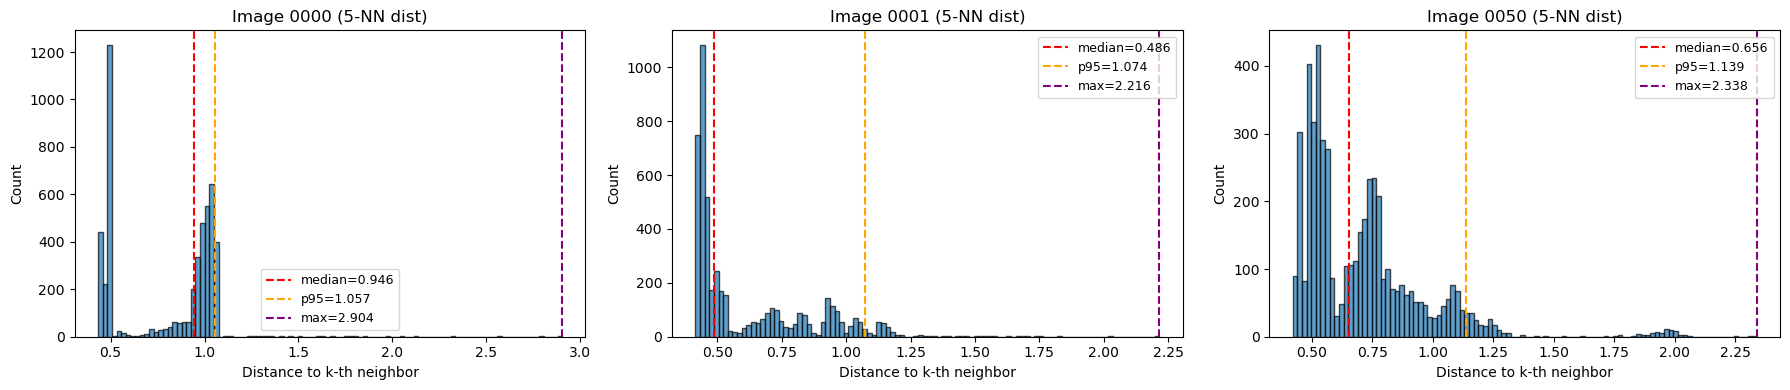

In [5]:
fig, axes = plt.subplots(1, len(IMAGE_INDICES), figsize=(6 * len(IMAGE_INDICES), 4))
if len(IMAGE_INDICES) == 1:
    axes = [axes]

for ax, idx in zip(axes, IMAGE_INDICES):
    dists = results[idx]["dists"]
    ax.hist(dists, bins=100, edgecolor="black", alpha=0.7)
    ax.axvline(np.median(dists), color="red", ls="--", label=f"median={np.median(dists):.3f}")
    ax.axvline(np.percentile(dists, 95), color="orange", ls="--", label=f"p95={np.percentile(dists, 95):.3f}")
    ax.axvline(dists.max(), color="purple", ls="--", label=f"max={dists.max():.3f}")
    ax.set_title(f"Image {idx:04d} ({MIN_NEIGHBORS}-NN dist)")
    ax.set_xlabel("Distance to k-th neighbor")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Radius별 커버리지 분석

주어진 radius에서 몇 %의 point가 최소 N개 이웃을 갖는지 확인합니다.

In [11]:
test_radii = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 5.0]

print(f"{'Radius':>8} | ", end="")
for idx in IMAGE_INDICES:
    print(f"  img{idx:04d}", end="")
print()
print("-" * (10 + 9 * len(IMAGE_INDICES)))

for r in test_radii:
    print(f"{r:>8.1f} | ", end="")
    for idx in IMAGE_INDICES:
        dists = results[idx]["dists"]
        coverage = (dists <= r).mean() * 100
        print(f"  {coverage:5.1f}%", end="")
    print()

  Radius |   img0000  img0001  img0010  img0030  img0050  img0070  img0090
-------------------------------------------------------------------------
     0.5 |    13.3%   54.8%   66.5%   33.8%   18.2%   22.6%   22.2%
     1.0 |    67.3%   91.2%   85.7%   99.7%   87.9%   76.1%   91.5%
     1.5 |    99.7%   99.6%   97.2%  100.0%   98.6%   99.9%   99.4%
     2.0 |    99.9%  100.0%   99.4%  100.0%   99.7%  100.0%   99.5%
     2.5 |    99.9%  100.0%   99.9%  100.0%  100.0%  100.0%   99.6%
     3.0 |   100.0%  100.0%  100.0%  100.0%  100.0%  100.0%   99.6%
     5.0 |   100.0%  100.0%  100.0%  100.0%  100.0%  100.0%   99.9%


## 6. 3D Point Cloud 시각화 (선택)

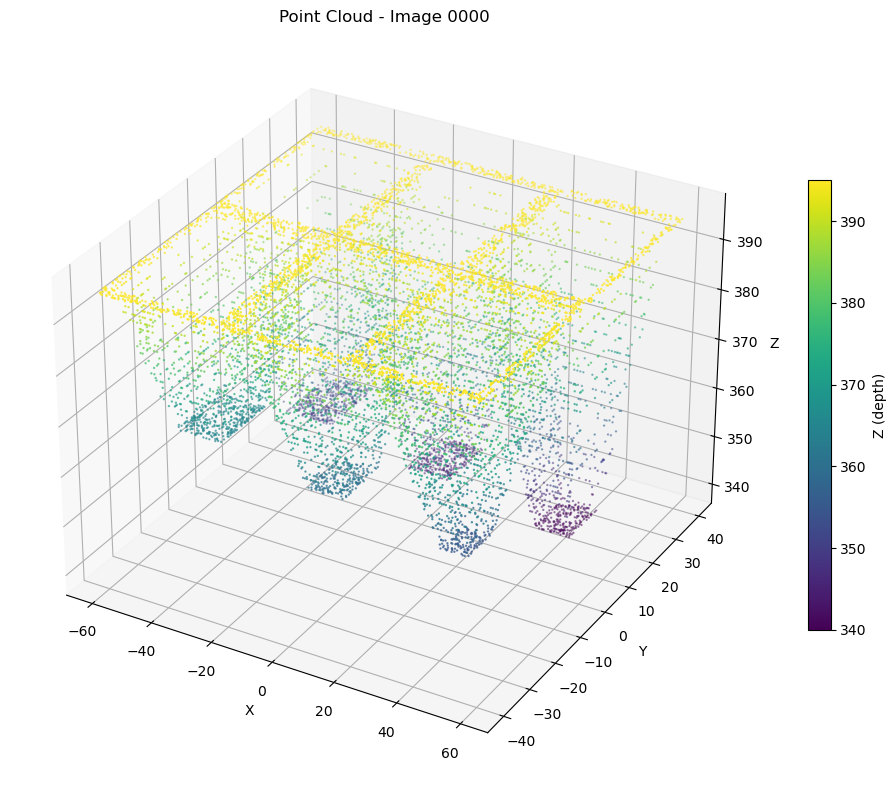

In [12]:
# 하나의 point cloud를 3D scatter로 시각화
vis_idx = IMAGE_INDICES[0]
pts = results[vis_idx]["points_3d"]

# 너무 많으면 다운샘플
if len(pts) > 10000:
    sel = np.random.choice(len(pts), 10000, replace=False)
    pts = pts[sel]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=pts[:, 2], cmap="viridis", s=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Point Cloud - Image {vis_idx:04d}")
plt.colorbar(sc, label="Z (depth)", shrink=0.6)
plt.tight_layout()
plt.show()